In [ ]:
# K-Means Definition--
# K-Means Clustering is an unsupervised machine learning algorithm that
# groups similar data points into K clusters based on distance from the centroid.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/mall - mall.csv")
df.head(3)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [ ]:
df = df.drop(columns=['CustomerID', 'Genre'])

In [ ]:
# df.head()

In [ ]:
x = df.iloc[:, [0,1]].values

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
import matplotlib.pyplot as plt

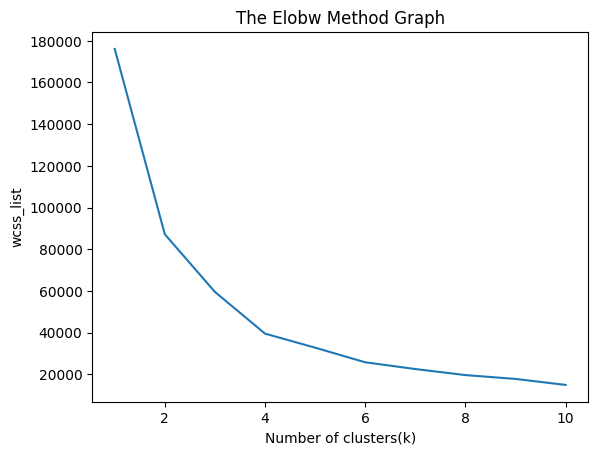

In [ ]:
# ALGO METHOD

a = []

for i in range(1,11):
  b = KMeans(n_clusters = i , init = 'k-means++' , random_state = 42)
  b.fit(x)
  a.append(b.inertia_)

  # inertia_ = WCSS value(Within Cluster Sum of Squares)
  # WCSS means:
  # Data points centroid se kitne close hain.

plt.plot(range(1,11) , a)

plt.title('The Elobw Method Graph')
plt.xlabel('Number of clusters(k)')
plt.ylabel('wcss_list')
plt.show()

# X-axis:
# Number of clusters

# Y-axis:
# WCSS values

# Jahan graph sharply bend hota hai → best K value.

From the above plot, we can see the elbow point is at 4. So the
number of clusters here will be 4.

In [ ]:
b = KMeans(n_clusters=4, init='k-means++', random_state= 42)
y_predict= b.fit_predict(x)

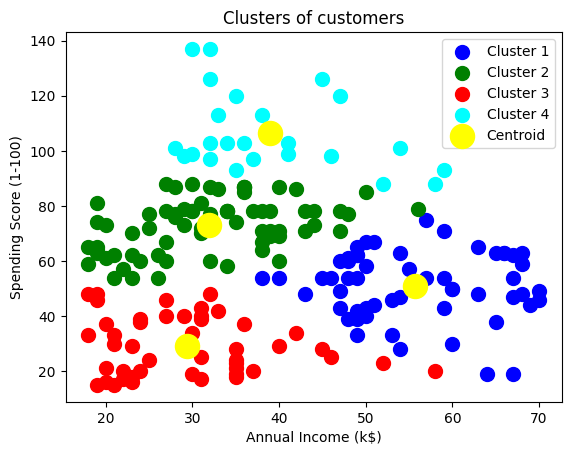

In [ ]:
#visulaizing the clusters
plt.scatter(x[y_predict == 0, 0], x[y_predict == 0, 1], s = 100, c = 'blue', label = 'Cluster 1')#for first cluster
plt.scatter(x[y_predict == 1, 0], x[y_predict == 1, 1], s = 100, c = 'green', label = 'Cluster 2')#for second cluster
plt.scatter(x[y_predict == 2, 0], x[y_predict == 2, 1], s = 100, c = 'red', label = 'Cluster 3')#for third cluster
plt.scatter(x[y_predict == 3, 0], x[y_predict == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4' )#for fourth cluster


# y_predict == 1
# → sirf un rows ko select karo jo Cluster 2 me hain.
# 0
# → first column values lo (X-axis values).


# x[y_predict == 1, 1] --
# Cluster 2 ki second column values lo.
# Ye Y-axis values hoti hain.


# har cluster ka center point bana rahe hai
plt.scatter(b.cluster_centers_[:, 0], b.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroid' )
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

### Evaluating K-Means Clustering with Silhouette Score
Since K-Means is an unsupervised algorithm, we don't have true labels to calculate 'accuracy'. Instead, we use internal validation metrics. The Silhouette Score is a popular choice, measuring how similar an object is to its own cluster compared to other clusters. The score ranges from -1 to 1, where:
- A score near +1 indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.
- A score near 0 indicates overlapping clusters.
- A score near -1 indicates that the object might have been assigned to the wrong cluster.

In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
silhouette_avg = silhouette_score(x, y_predict)

print(f"The Silhouette Score for the K-Means clustering is: {silhouette_avg:.3f}")

The Silhouette Score for the K-Means clustering is: 0.434


In [ ]:
# CENTROID --->
# A Centroid is the center point of a cluster in Machine Learning, especially in the K-means Clustering algorithm.